# Nonlinearity and Kernel Methods

Machine learning models often begin with a simple assumption:

> The relationship between the input features and the target can be represented using a linear function.

Linear models work very well when the data has a roughly linear relationship.

However, many real-world datasets contain **nonlinear patterns**.

Examples include:

- Circular decision boundaries
- Curved relationships
- XOR-like patterns
- Complex clusters
- Interactions between features

When a linear model cannot represent these patterns, we need methods that can model **nonlinearity**.

One important approach is to transform the original features into a higher-dimensional feature space.

Kernel methods provide an efficient way to perform this transformation without explicitly computing all the new features.

In this notebook, we will learn:

- Why nonlinear models are needed
- How feature transformations introduce nonlinearity
- What the kernel trick means
- How kernel functions work
- Common kernel functions
- Polynomial and RBF kernels
- How kernels are used with Support Vector Machines
- How to visualize nonlinear decision boundaries

# Nonlinearity and Kernel Methods

Machine learning models often try to learn a relationship between input features and the target.

A **linear model** assumes that this relationship can be represented using a linear equation.

For example, with two features:

$$
y = w_1x_1 + w_2x_2 + b
$$

For classification, a linear model produces a linear decision boundary:

$$
w_1x_1 + w_2x_2 + b = 0
$$

This works well when the data can be separated using a straight line.

However, many real-world datasets contain **nonlinear relationships**.

Examples include:

- Circular patterns
- Curved patterns
- XOR-like patterns
- Complex class boundaries
- Feature interactions

For these problems, a straight line is not sufficient.

This notebook introduces the idea of **nonlinearity** and explains how **kernel methods** allow algorithms such as Support Vector Machines to learn nonlinear patterns.

We will study:

1. What nonlinearity means
2. Linear vs nonlinear decision boundaries
3. Why linear models fail on nonlinear data
4. Feature transformations
5. Polynomial features
6. Feature mapping
7. The kernel trick
8. Kernel functions
9. Common kernel types
10. Polynomial kernel
11. RBF / Gaussian kernel
12. The effect of hyperparameters
13. Nonlinear SVM
14. Decision boundary visualization
15. Practical kernel selection
16. Advantages and limitations

# 1. What Is Nonlinearity?

Before understanding kernel methods, we need to understand what **nonlinearity** means.

A relationship is called **linear** when it can be represented using a linear equation.

For example:

$$
y = 2x + 3
$$

This produces a straight line.

For multiple features:

$$
y = w_1x_1 + w_2x_2 + b
$$

the relationship is still linear.

For classification, the corresponding decision boundary is:

$$
w_1x_1 + w_2x_2 + b = 0
$$

In two dimensions, this boundary is a straight line.

In higher dimensions, it is called a **hyperplane**.

---

A nonlinear relationship cannot be represented adequately using a single linear equation.

For example:

$$
y = x^2
$$

produces a curve rather than a straight line.

Similarly:

$$
x_1^2 + x_2^2 = r^2
$$

represents a circle.

Therefore, nonlinear machine learning models are needed when the relationship between features and the target is more complex than a straight line or hyperplane.

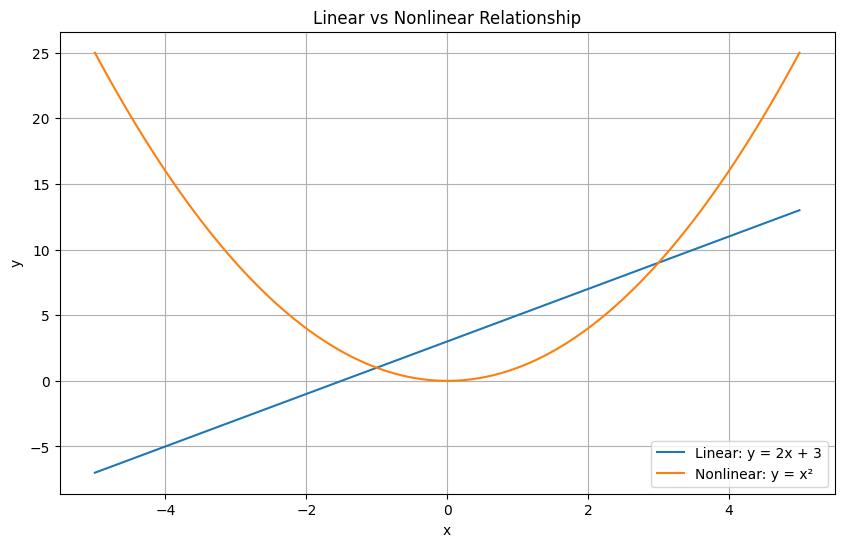

In [1]:
# Import the libraries we will use throughout this notebook

import numpy as np
import matplotlib.pyplot as plt

# Create some values for x
x = np.linspace(-5, 5, 100)

# Linear relationship
y_linear = 2 * x + 3

# Nonlinear relationship
y_nonlinear = x ** 2

# Create the plot
plt.figure(figsize=(10, 6))

plt.plot(
    x,
    y_linear,
    label="Linear: y = 2x + 3"
)

plt.plot(
    x,
    y_nonlinear,
    label="Nonlinear: y = x²"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Nonlinear Relationship")

plt.legend()
plt.grid(True)

plt.show()

## Observation

The first relationship:

$$
y = 2x + 3
$$

produces a straight line.

The second relationship:

$$
y = x^2
$$

produces a curve.

The important difference is that the linear relationship can be represented using a linear equation, while the second relationship contains a nonlinear term:

$$
x^2
$$

This simple idea becomes very important in machine learning.

If the true structure of the data is nonlinear, a purely linear model may not be able to learn the correct pattern.

# 2. Linear Decision Boundary

In classification, a linear model separates classes using a linear decision boundary.

For two features, the general form is:

$$
w_1x_1 + w_2x_2 + b = 0
$$

where:

- $x_1, x_2$ are the input features
- $w_1, w_2$ are model weights
- $b$ is the bias

The model predicts one class on one side of the boundary and another class on the other side.

For example:

$$
x_1 + x_2 - 1 = 0
$$

can be rewritten as:

$$
x_2 = 1 - x_1
$$

which is a straight line.

Therefore, a linear classifier can only create a linear boundary in the original feature space.

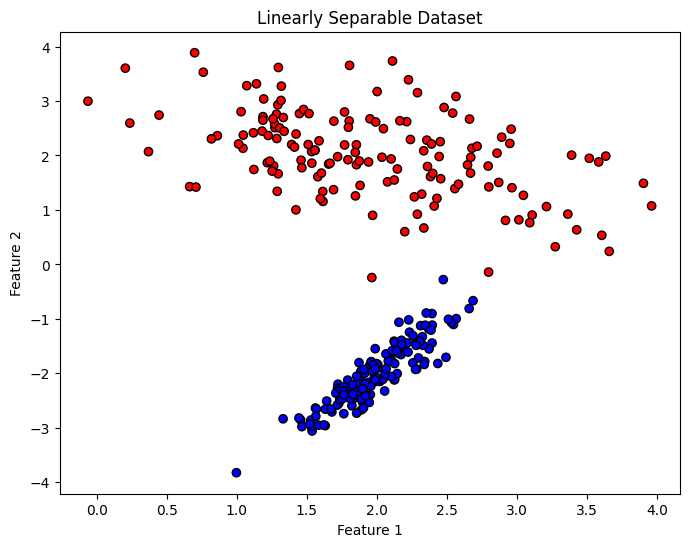

In [2]:
# Create a simple linearly separable dataset

from sklearn.datasets import make_classification

X_linear, y_linear_class = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42
)

# Visualize the dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    X_linear[:, 0],
    X_linear[:, 1],
    c=y_linear_class,
    cmap="bwr",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearly Separable Dataset")

plt.show()

## Observation

The two classes in this dataset can approximately be separated using a straight line.

Therefore, a linear classifier is suitable for this type of problem.

But not every dataset has this structure.

Let's now create a nonlinear dataset.

# 3. Nonlinearly Separable Data

A dataset is **nonlinearly separable** when a single linear decision boundary cannot correctly separate the classes.

One common example is a circular dataset.

Suppose one class is located in the center and another class surrounds it.

A straight line cannot separate the two classes correctly because the outer class surrounds the inner class.

This type of problem requires a nonlinear decision boundary.

We will use the `make_circles()` dataset from scikit-learn to demonstrate this.

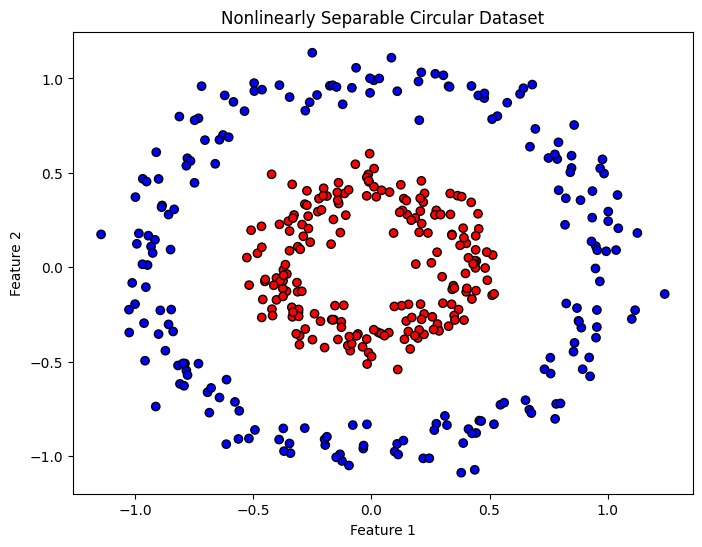

In [3]:
from sklearn.datasets import make_circles

# Create a nonlinear circular dataset

X, y = make_circles(
    n_samples=400,
    noise=0.08,
    factor=0.4,
    random_state=42
)

# Visualize the dataset

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinearly Separable Circular Dataset")

plt.show()

## Understanding the Dataset

The dataset contains two classes.

The first class forms an inner circle.

The second class forms an outer circle.

The classes are clearly different, but they cannot be separated by a single straight line.

This is an important distinction:

> A dataset can be easy to understand visually but still be impossible for a linear classifier to separate correctly.

We therefore need a method that can create a **nonlinear decision boundary**.

# 4. Linear SVM on Nonlinear Data

Support Vector Machines can use different kernels.

If we use:

$$
\text{kernel} = \text{"linear"}
$$

the SVM produces a linear decision boundary.

Let's apply a linear SVM to our circular dataset.

This will demonstrate why a nonlinear method is necessary.

In [4]:
from sklearn.svm import SVC

# Create a linear SVM
linear_svm = SVC(
    kernel="linear",
    C=1
)

# Train the model
linear_svm.fit(X, y)

# Calculate training accuracy
linear_accuracy = linear_svm.score(X, y)

print("Linear SVM Training Accuracy:", linear_accuracy)

Linear SVM Training Accuracy: 0.5825


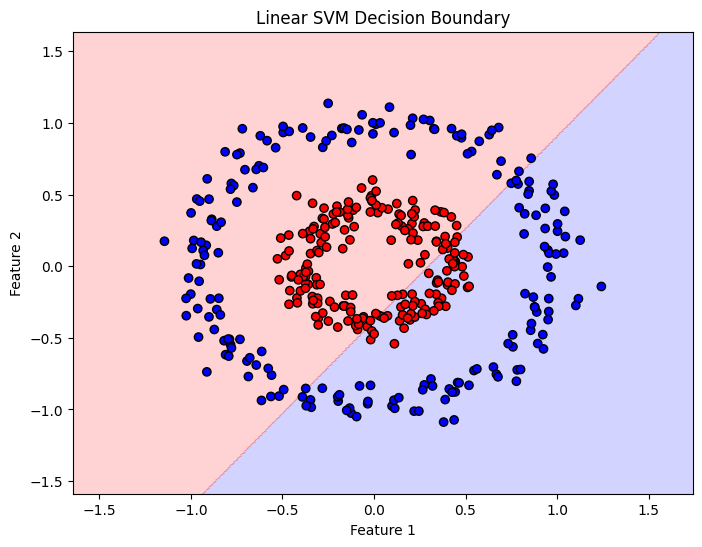

In [5]:
# Create a grid of points for visualizing the decision boundary

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5

y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Combine grid coordinates
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for every point in the grid
Z = linear_svm.predict(grid)

# Reshape predictions back into grid format
Z = Z.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2,
    cmap="bwr"
)

# Plot the original observations
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM Decision Boundary")

plt.show()

## Why Does the Linear SVM Fail?

The linear SVM can only create a straight decision boundary.

But our dataset requires a boundary similar to a circle.

Therefore, the model cannot properly separate the two classes.

This gives us the central problem that kernel methods try to solve:

$$
\boxed{
\text{How can we make a linear algorithm learn nonlinear patterns?}
}
$$

One solution is to transform the original features.

# 5. Feature Transformation

Suppose our original features are:

$$
x_1,\;x_2
$$

We can create additional features such as:

$$
x_1^2,\quad x_2^2,\quad x_1x_2
$$

Now the model works with:

$$
x_1,\;x_2,\;x_1^2,\;x_2^2,\;x_1x_2
$$

This is called **feature transformation** or **feature mapping**.

The important idea is that the model can remain linear with respect to the transformed features while producing a nonlinear boundary in the original feature space.

For example, consider:

$$
z = x_1^2 + x_2^2
$$

A linear rule in the transformed feature $z$:

$$
z = r^2
$$

becomes:

$$
x_1^2 + x_2^2 = r^2
$$

in the original feature space.

That equation represents a circle.

Therefore, transforming features can allow a linear model to represent nonlinear patterns.

In [6]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features of degree 2
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Transform the original features
X_poly = poly.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_poly.shape)

Original shape: (400, 2)
Transformed shape: (400, 5)


In [7]:
# Display the names of the generated polynomial features

feature_names = poly.get_feature_names_out(
    ["x1", "x2"]
)

print("Polynomial Features:")

for name in feature_names:
    print(name)

Polynomial Features:
x1
x2
x1^2
x1 x2
x2^2


## What Happened?

Originally, we had only two features:

$$
x_1,\;x_2
$$

After applying a degree-2 polynomial transformation, we obtain additional features such as:

$$
x_1^2
$$

$$
x_1x_2
$$

$$
x_2^2
$$

The model now has access to nonlinear information.

However, there is a problem.

If we have many original features and use a high polynomial degree, the number of generated features can become extremely large.

For example, a transformation can produce thousands or even millions of features.

This can become computationally expensive.

The **kernel trick** provides an elegant solution.

# 6. Feature Mapping

Feature mapping means transforming the original feature vector into another feature space.

We can write this transformation as:

$$
\phi(x)
$$

where $\phi$ is the feature mapping function.

For example:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

could be mapped to:

$$
\phi(x)
=
\begin{bmatrix}
x_1 \\
x_2 \\
x_1^2 \\
x_1x_2 \\
x_2^2
\end{bmatrix}
$$

The original data exists in a two-dimensional space.

After transformation, the data exists in a higher-dimensional space.

A pattern that is nonlinear in the original space may become easier to separate using a linear boundary in the transformed space.

This is the fundamental idea behind kernel methods.

# 8. What Is a Kernel Function?

A **kernel function** takes two observations as input and returns a measure of their relationship or similarity.

In general:

$$
K(x,z)
$$

takes:

- $x$ = first observation
- $z$ = second observation

and returns a numerical value.

Different kernel functions define similarity differently.

The most common kernels used with SVM are:

1. Linear kernel
2. Polynomial kernel
3. RBF / Gaussian kernel
4. Sigmoid kernel

The choice of kernel determines the type of nonlinear relationship the model can represent.

# 9. Linear Kernel

The linear kernel is:

$$
K(x,z)=x^Tz
$$

This is simply the dot product between two feature vectors.

The linear kernel does not introduce nonlinear behavior.

Therefore:

```text
Linear SVM
    ↓
Linear Kernel
    ↓
Linear Decision Boundary


# 10. Polynomial Kernel

The polynomial kernel is commonly written as:

$$
K(x,z)
=
(\gamma x^Tz + r)^d
$$

where:

- $d$ = degree of the polynomial
- $\gamma$ = scaling parameter
- $r$ = coefficient

The degree controls the complexity of the polynomial relationship.

For example:

$$
d=2
$$

allows quadratic relationships.

While:

$$
d=3
$$

allows cubic relationships.

Higher values of $d$ can produce more complex decision boundaries.

However, increasing model complexity can also increase the risk of overfitting.

In [8]:
# Train an SVM using a polynomial kernel

poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1
)

poly_svm.fit(X, y)

# Evaluate training accuracy
poly_accuracy = poly_svm.score(X, y)

print("Polynomial SVM Training Accuracy:", poly_accuracy)

Polynomial SVM Training Accuracy: 0.675


# 11. RBF / Gaussian Kernel

The **Radial Basis Function (RBF)** kernel is one of the most commonly used nonlinear kernels.

It is also called the **Gaussian kernel**.

The RBF kernel is:

$$
K(x,z)
=
\exp
\left(
-\gamma ||x-z||^2
\right)
$$

Here:

$$
||x-z||^2
$$

represents the squared Euclidean distance between the two observations.

The RBF kernel therefore depends on how close two observations are.

If two observations are very close:

$$
||x-z||^2 \approx 0
$$

then:

$$
K(x,z) \approx 1
$$

If two observations are far apart:

$$
||x-z||^2
$$

becomes large and the kernel value approaches zero.

Therefore, the RBF kernel gives a high similarity value to nearby observations and a low similarity value to distant observations.

# 12. Understanding Gamma

The parameter $\gamma$ is very important for the RBF kernel.

The RBF kernel is:

$$
K(x,z)
=
\exp
\left(
-\gamma ||x-z||^2
\right)
$$

Gamma controls how quickly the similarity decreases as the distance increases.

### Small Gamma

With a small value of $\gamma$, each training point has a broader area of influence.

The decision boundary tends to be smoother.

This may cause underfitting if $\gamma$ is too small.

### Large Gamma

With a large value of $\gamma$, each training point has a smaller area of influence.

The model can create a much more flexible decision boundary.

If $\gamma$ becomes too large, the model may fit noise in the training data.

This can lead to overfitting.

Therefore:

$$
\text{Small }\gamma
\rightarrow
\text{Smoother boundary}
$$

$$
\text{Large }\gamma
\rightarrow
\text{More complex boundary}
$$

In [9]:
# Train an SVM using the RBF kernel

rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(X, y)

# Calculate training accuracy
rbf_accuracy = rbf_svm.score(X, y)

print("RBF SVM Training Accuracy:", rbf_accuracy)

RBF SVM Training Accuracy: 1.0


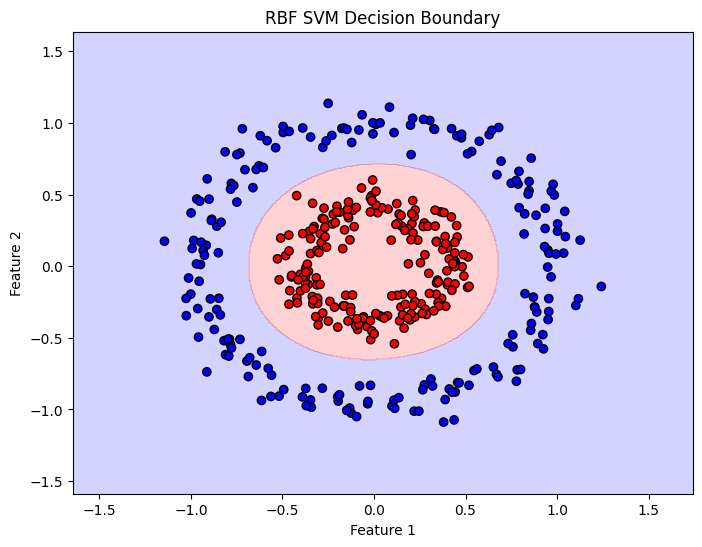

In [10]:
# Visualize the RBF SVM decision boundary

Z = rbf_svm.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Plot decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2,
    cmap="bwr"
)

# Plot the observations
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("RBF SVM Decision Boundary")

plt.show()

## Observation

The RBF SVM is able to create a curved decision boundary.

This is exactly what the circular dataset requires.

Compare this with the linear SVM.

The linear SVM could only create:

$$
\text{straight boundary}
$$

while the RBF SVM can create:

$$
\text{nonlinear boundary}
$$

This is the main practical use of kernel methods with SVM.

The model is still an SVM, but the kernel allows it to work with nonlinear relationships.

# 13. Comparing Linear, Polynomial, and RBF Kernels

We have now used three different kernels:

### Linear

$$
K(x,z)=x^Tz
$$

Produces a linear decision boundary.

### Polynomial

$$
K(x,z)
=
(\gamma x^Tz+r)^d
$$

Can produce polynomial nonlinear boundaries.

### RBF

$$
K(x,z)
=
\exp(-\gamma||x-z||^2)
$$

Can produce flexible nonlinear boundaries.

The important point is:

> The kernel changes how the SVM measures relationships between observations and therefore changes the type of decision boundary the model can learn.

In [11]:
# Compare training accuracy of different kernels

print("Linear Kernel Accuracy:     ", linear_svm.score(X, y))
print("Polynomial Kernel Accuracy: ", poly_svm.score(X, y))
print("RBF Kernel Accuracy:        ", rbf_svm.score(X, y))

Linear Kernel Accuracy:      0.5825
Polynomial Kernel Accuracy:  0.675
RBF Kernel Accuracy:         1.0


# 14. Effect of Gamma

Let's investigate the effect of different gamma values.

We will train three RBF SVM models using:

$$
\gamma = 0.1
$$

$$
\gamma = 1
$$

and:

$$
\gamma = 10
$$

The purpose is not simply to find the best accuracy.

The purpose is to understand how gamma changes the shape and complexity of the decision boundary.

In [12]:
# Different gamma values
gamma_values = [0.1, 1, 10]

# Store trained models
gamma_models = []

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    model.fit(X, y)

    gamma_models.append(model)

    print(
        f"Gamma = {gamma}, "
        f"Training Accuracy = {model.score(X, y):.4f}"
    )

Gamma = 0.1, Training Accuracy = 1.0000
Gamma = 1, Training Accuracy = 1.0000
Gamma = 10, Training Accuracy = 1.0000


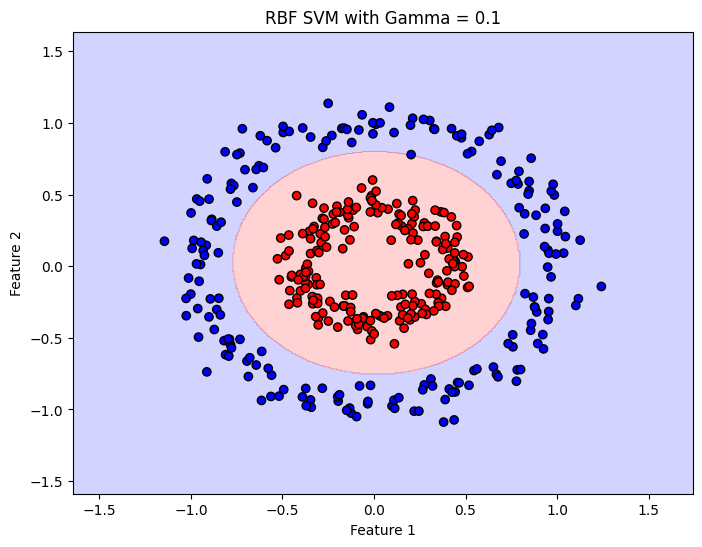

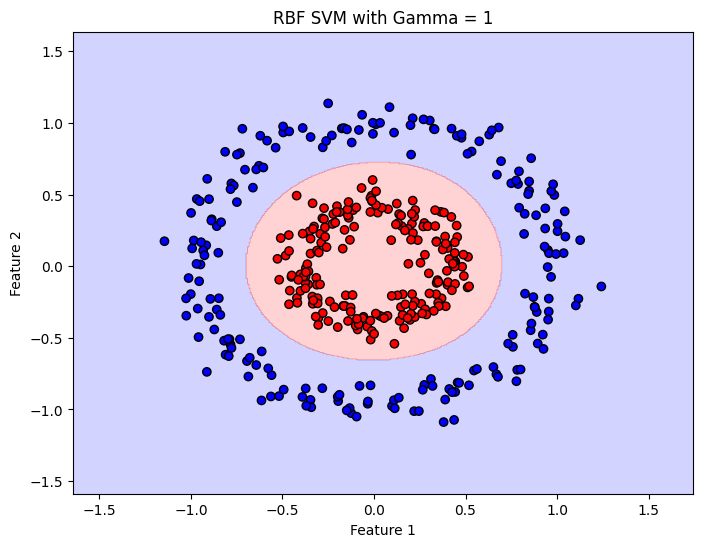

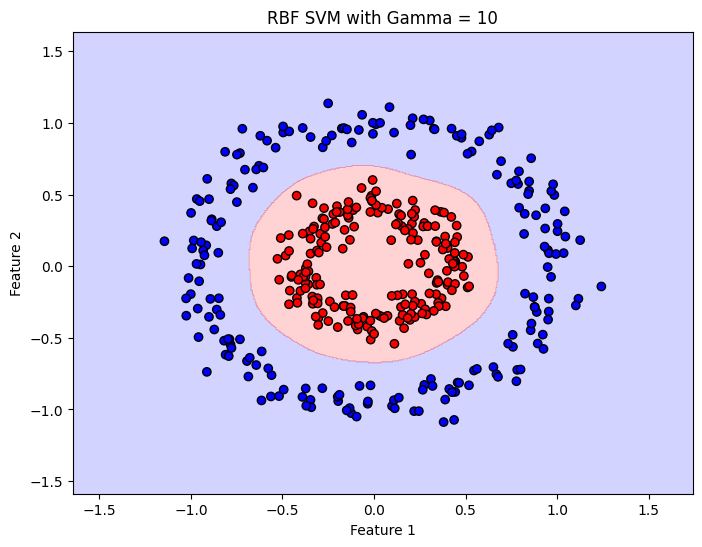

In [13]:
# Visualize the decision boundary for each gamma value

for gamma, model in zip(gamma_values, gamma_models):

    # Predict for every point in the grid
    Z = model.predict(grid)

    # Reshape predictions
    Z = Z.reshape(xx.shape)

    # Create a new figure
    plt.figure(figsize=(8, 6))

    # Plot decision regions
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.2,
        cmap="bwr"
    )

    # Plot observations
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="bwr",
        edgecolor="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"RBF SVM with Gamma = {gamma}")

    plt.show()

## Gamma Interpretation

From the visualizations, we can see that gamma affects the flexibility of the decision boundary.

### Low Gamma

The model creates a smoother and broader boundary.

If gamma is too small, the model may be unable to capture important patterns.

This is a form of **underfitting**.

### High Gamma

The model becomes more sensitive to individual observations.

The boundary can become highly flexible.

If gamma is too large, the model may begin fitting noise.

This is a form of **overfitting**.

Therefore, gamma is a model-complexity parameter.

It should normally be selected using validation or cross-validation rather than chosen arbitrarily.

# 15. Effect of C in a Nonlinear SVM

The parameter $C$ controls how strongly the SVM penalizes classification errors.

### Small C

A small value of $C$ allows more training errors.

The model focuses more on finding a reasonable margin rather than perfectly classifying every training observation.

This provides stronger regularization.

### Large C

A large value of $C$ strongly penalizes training errors.

The model tries harder to classify training observations correctly.

This can produce a more complex decision boundary.

Therefore:

$$
\text{Small }C
\rightarrow
\text{More regularization}
$$

$$
\text{Large }C
\rightarrow
\text{Less regularization}
$$

For an RBF SVM, both $C$ and $\gamma$ influence model complexity.

In [14]:
# Compare different C values

C_values = [0.1, 1, 100]

for C in C_values:

    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale"
    )

    model.fit(X, y)

    accuracy = model.score(X, y)

    print(
        f"C = {C}, "
        f"Training Accuracy = {accuracy:.4f}"
    )

C = 0.1, Training Accuracy = 1.0000
C = 1, Training Accuracy = 1.0000
C = 100, Training Accuracy = 1.0000


# 16. Why Feature Scaling Matters

Kernel methods, especially the RBF kernel, are sensitive to distances.

The RBF kernel uses:

$$
||x-z||^2
$$

which is a distance calculation.

Suppose we have two features:

$$
\text{Age} = 18 \text{ to } 80
$$

and:

$$
\text{Income} = 20,000 \text{ to } 200,000
$$

The income feature has a much larger numerical scale.

As a result, it can dominate the distance calculation.

This can negatively affect the kernel.

Therefore, feature scaling is generally recommended before using distance-sensitive kernels such as RBF.

A common approach is standardization:

$$
z =
\frac{x-\mu}{\sigma}
$$

where:

- $\mu$ = mean
- $\sigma$ = standard deviation

After standardization, features are placed on a comparable scale.

In [15]:
from sklearn.preprocessing import StandardScaler

# Create a scaler
scaler = StandardScaler()

# Fit the scaler using the data and transform it
X_scaled = scaler.fit_transform(X)

# Check the mean and standard deviation
print("Mean of scaled features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(axis=0))

Mean of scaled features:
[8.32667268e-18 3.59434704e-17]

Standard deviation of scaled features:
[1. 1.]


# 17. Complete Nonlinear SVM Workflow

A typical nonlinear SVM workflow is:

```text
Raw Data
    ↓
Train/Test Split
    ↓
Feature Scaling
    ↓
Choose Kernel
    ↓
Select C and Other Hyperparameters
    ↓
Train SVM
    ↓
Evaluate on Test Data
    ↓
Tune Hyperparameters if Necessary

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [17]:
# Create the scaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (320, 2)
Testing data shape: (80, 2)


In [18]:
# Create the final nonlinear SVM

final_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

# Train the model
final_model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed.")

Model training completed.


In [19]:
from sklearn.metrics import accuracy_score

# Make predictions

y_train_pred = final_model.predict(X_train_scaled)
y_test_pred = final_model.predict(X_test_scaled)

# Calculate accuracy

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 1.0


## Interpreting Training and Test Accuracy

Training accuracy tells us how well the model performs on data it has already seen.

Test accuracy tells us how well the model performs on unseen data.

A model should not be judged only by its training accuracy.

For example:

$$
\text{Training Accuracy} = 99\%
$$

but:

$$
\text{Test Accuracy} = 75\%
$$

could indicate overfitting.

A better situation is when training and test performance are both strong and reasonably close.

The goal of machine learning is **generalization**:

> The model should learn patterns that also work on new, unseen observations.

# 18. Other Common Kernels

SVM supports several kernel types.

## Linear Kernel

$$
K(x,z)=x^Tz
$$

Used for approximately linear relationships.

---

## Polynomial Kernel

$$
K(x,z)
=
(\gamma x^Tz+r)^d
$$

Useful when polynomial relationships are appropriate.

---

## RBF Kernel

$$
K(x,z)
=
\exp(-\gamma||x-z||^2)
$$

One of the most widely used kernels for nonlinear relationships.

---

## Sigmoid Kernel

$$
K(x,z)
=
\tanh(\gamma x^Tz+r)
$$

The sigmoid kernel has a form related to activation functions used in neural networks.

In practice, linear and RBF kernels are especially common, while polynomial and sigmoid kernels are useful in specific situations.

# 19. Kernel Methods Beyond SVM

The idea of kernels is not limited to Support Vector Machines.

Kernel methods can be used in several machine learning algorithms.

Examples include:

### Kernel Ridge Regression

Combines ridge regression with kernel methods to model nonlinear relationships.

### Kernel PCA

Extends Principal Component Analysis to nonlinear feature structures.

### Gaussian Processes

Use kernel functions to describe relationships between observations.

### Kernel Regression

Uses kernel-based similarity to estimate nonlinear relationships.

Therefore, the kernel trick is a broader machine learning concept.

It is not simply an SVM feature.

# 20. Advantages of Kernel Methods

Kernel methods have several advantages.

### 1. Can Model Nonlinear Relationships

They can learn decision boundaries that are impossible for a linear model to represent.

### 2. Powerful Feature Representation

The kernel implicitly represents relationships in a higher-dimensional feature space.

### 3. Avoid Explicit Feature Expansion

The kernel trick can avoid constructing all transformed features explicitly.

### 4. Flexible

Different kernels allow different types of relationships to be modeled.

### 5. Strong Performance on Medium-Sized Datasets

Kernel SVMs can work very well when the dataset is not extremely large.

# 21. Limitations of Kernel Methods

Kernel methods also have important limitations.

### 1. Computational Cost

Kernel SVMs can become expensive when the number of training observations becomes very large.

### 2. Hyperparameter Sensitivity

Performance can depend strongly on parameters such as:

$$
C,\quad \gamma,\quad d
$$

where $d$ is the polynomial degree.

### 3. Feature Scaling

Distance-based kernels such as RBF generally require careful feature scaling.

### 4. Kernel Selection

There is no universally best kernel.

The appropriate kernel depends on the dataset.

### 5. Interpretability

A nonlinear kernel model is generally harder to interpret than a simple linear model.

# 22. Practical Kernel Selection

There is no single kernel that is always the best.

A practical approach is:

### Start with a Linear Kernel

Use a linear kernel when:

- The data is approximately linearly separable.
- You have a very large number of features.
- You want a relatively simple model.

### Try an RBF Kernel

Use an RBF kernel when:

- The relationship is clearly nonlinear.
- You do not know the appropriate feature transformation.
- The dataset is reasonably sized.

### Try a Polynomial Kernel

Use a polynomial kernel when:

- You expect polynomial relationships.
- Feature interactions are important.
- You have a reason to control the polynomial degree.

Hyperparameters should be selected using validation or cross-validation.

A good default workflow is:

$$
\text{Scale Features}
\rightarrow
\text{Try Linear}
\rightarrow
\text{Try RBF}
\rightarrow
\text{Tune Hyperparameters}
$$

# 23. Kernel Methods vs Explicit Feature Transformation

There are two related approaches for introducing nonlinearity.

## Approach 1: Explicit Feature Transformation

We explicitly create:

$$
\phi(x)
$$

For example:

$$
x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2
$$

Then train a model using these transformed features.

### Advantage

We can directly inspect the generated features.

### Disadvantage

The number of features can become very large.

---

## Approach 2: Kernel Trick

Instead of explicitly constructing $\phi(x)$, we calculate:

$$
K(x,z)
=
\phi(x)^T\phi(z)
$$

### Advantage

We can work with a high-dimensional feature space without explicitly creating all transformed features.

### Disadvantage

Kernel methods can become computationally expensive for very large datasets.

Therefore, the kernel trick provides an efficient mathematical way to work with certain high-dimensional feature spaces.

# 24. Important Concept: Kernel vs Model

A kernel is **not the same thing as a machine learning model**.

For example:

```text
SVM
│
├── Linear Kernel
├── Polynomial Kernel
├── RBF Kernel
└── Sigmoid Kernel

Here:

SVM is the learning algorithm.
Kernel determines how relationships between observations are represented.

Therefore:

$$ \text{SVM + Linear Kernel} $$

produces a linear SVM.

While:

$$ \text{SVM + RBF Kernel} $$

produces a nonlinear SVM.


---


# 25. Final Conceptual Picture

The complete idea can be summarized as follows.

### Linear Model

Original feature space:

$$
x
$$

↓

Linear decision boundary

↓

May fail on nonlinear data.

---

### Explicit Feature Mapping

Original features:

$$
x
$$

↓

Feature transformation:

$$
\phi(x)
$$

↓

Higher-dimensional feature space

↓

Linear boundary in transformed space

↓

Nonlinear boundary in original space.

---

### Kernel Trick

Instead of explicitly calculating:

$$
\phi(x)
$$

we calculate:

$$
K(x,z)
=
\phi(x)^T\phi(z)
$$

↓

The algorithm can work with the transformed representation implicitly.

This is the central idea of kernel methods.

# 27. What We Should Remember

The complete flow is:

$$
\boxed{
\text{Nonlinear Data}
\rightarrow
\text{Feature Mapping}
\rightarrow
\text{Higher-Dimensional Space}
\rightarrow
\text{Linear Separation}
}
$$

The kernel trick allows us to perform the important calculations associated with this transformation without explicitly creating the entire high-dimensional feature space.

For SVM:

$$
\boxed{
\text{SVM + Kernel}
\rightarrow
\text{Nonlinear Decision Boundary}
}
$$

The three concepts you should be able to explain after this notebook are:

1. **Why a linear model can fail on nonlinear data**
2. **How feature mapping can make nonlinear data easier to separate**
3. **How the kernel trick performs this idea efficiently**

These three ideas form the foundation of kernel methods.